In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.gridspec as gridspec
import torch
import os
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  
from matplotlib import cm  
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import jax.numpy as jnp
import jax
from types import SimpleNamespace
from scipy.special import logsumexp
import seaborn as sns
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import pandas as pd


plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")
output_data_ex2 = os.path.join(base_dir,  "Experiment1_Tripendulum", "optimisation", "output_data")
input_data_ex2 = os.path.join(base_dir,  "Experiment1_Tripendulum", "input_data")
def load_run(data_dir, fname, printing = False):
    """Load a results .npz file and return its arrays as torch tensors in a namespace."""
    raw = np.load(os.path.join(data_dir, fname), allow_pickle = True)
    ns = SimpleNamespace()
    for key in raw:
        if printing:
            print(key)
        try:
            setattr(ns, key, torch.tensor(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Inverse problem

['GT standard', 'GT extra_npoints_extra_sigma', 'PIGP standard', 'GT standard', 'GT extra_npoints_extra_sigma', 'PIGP standard']


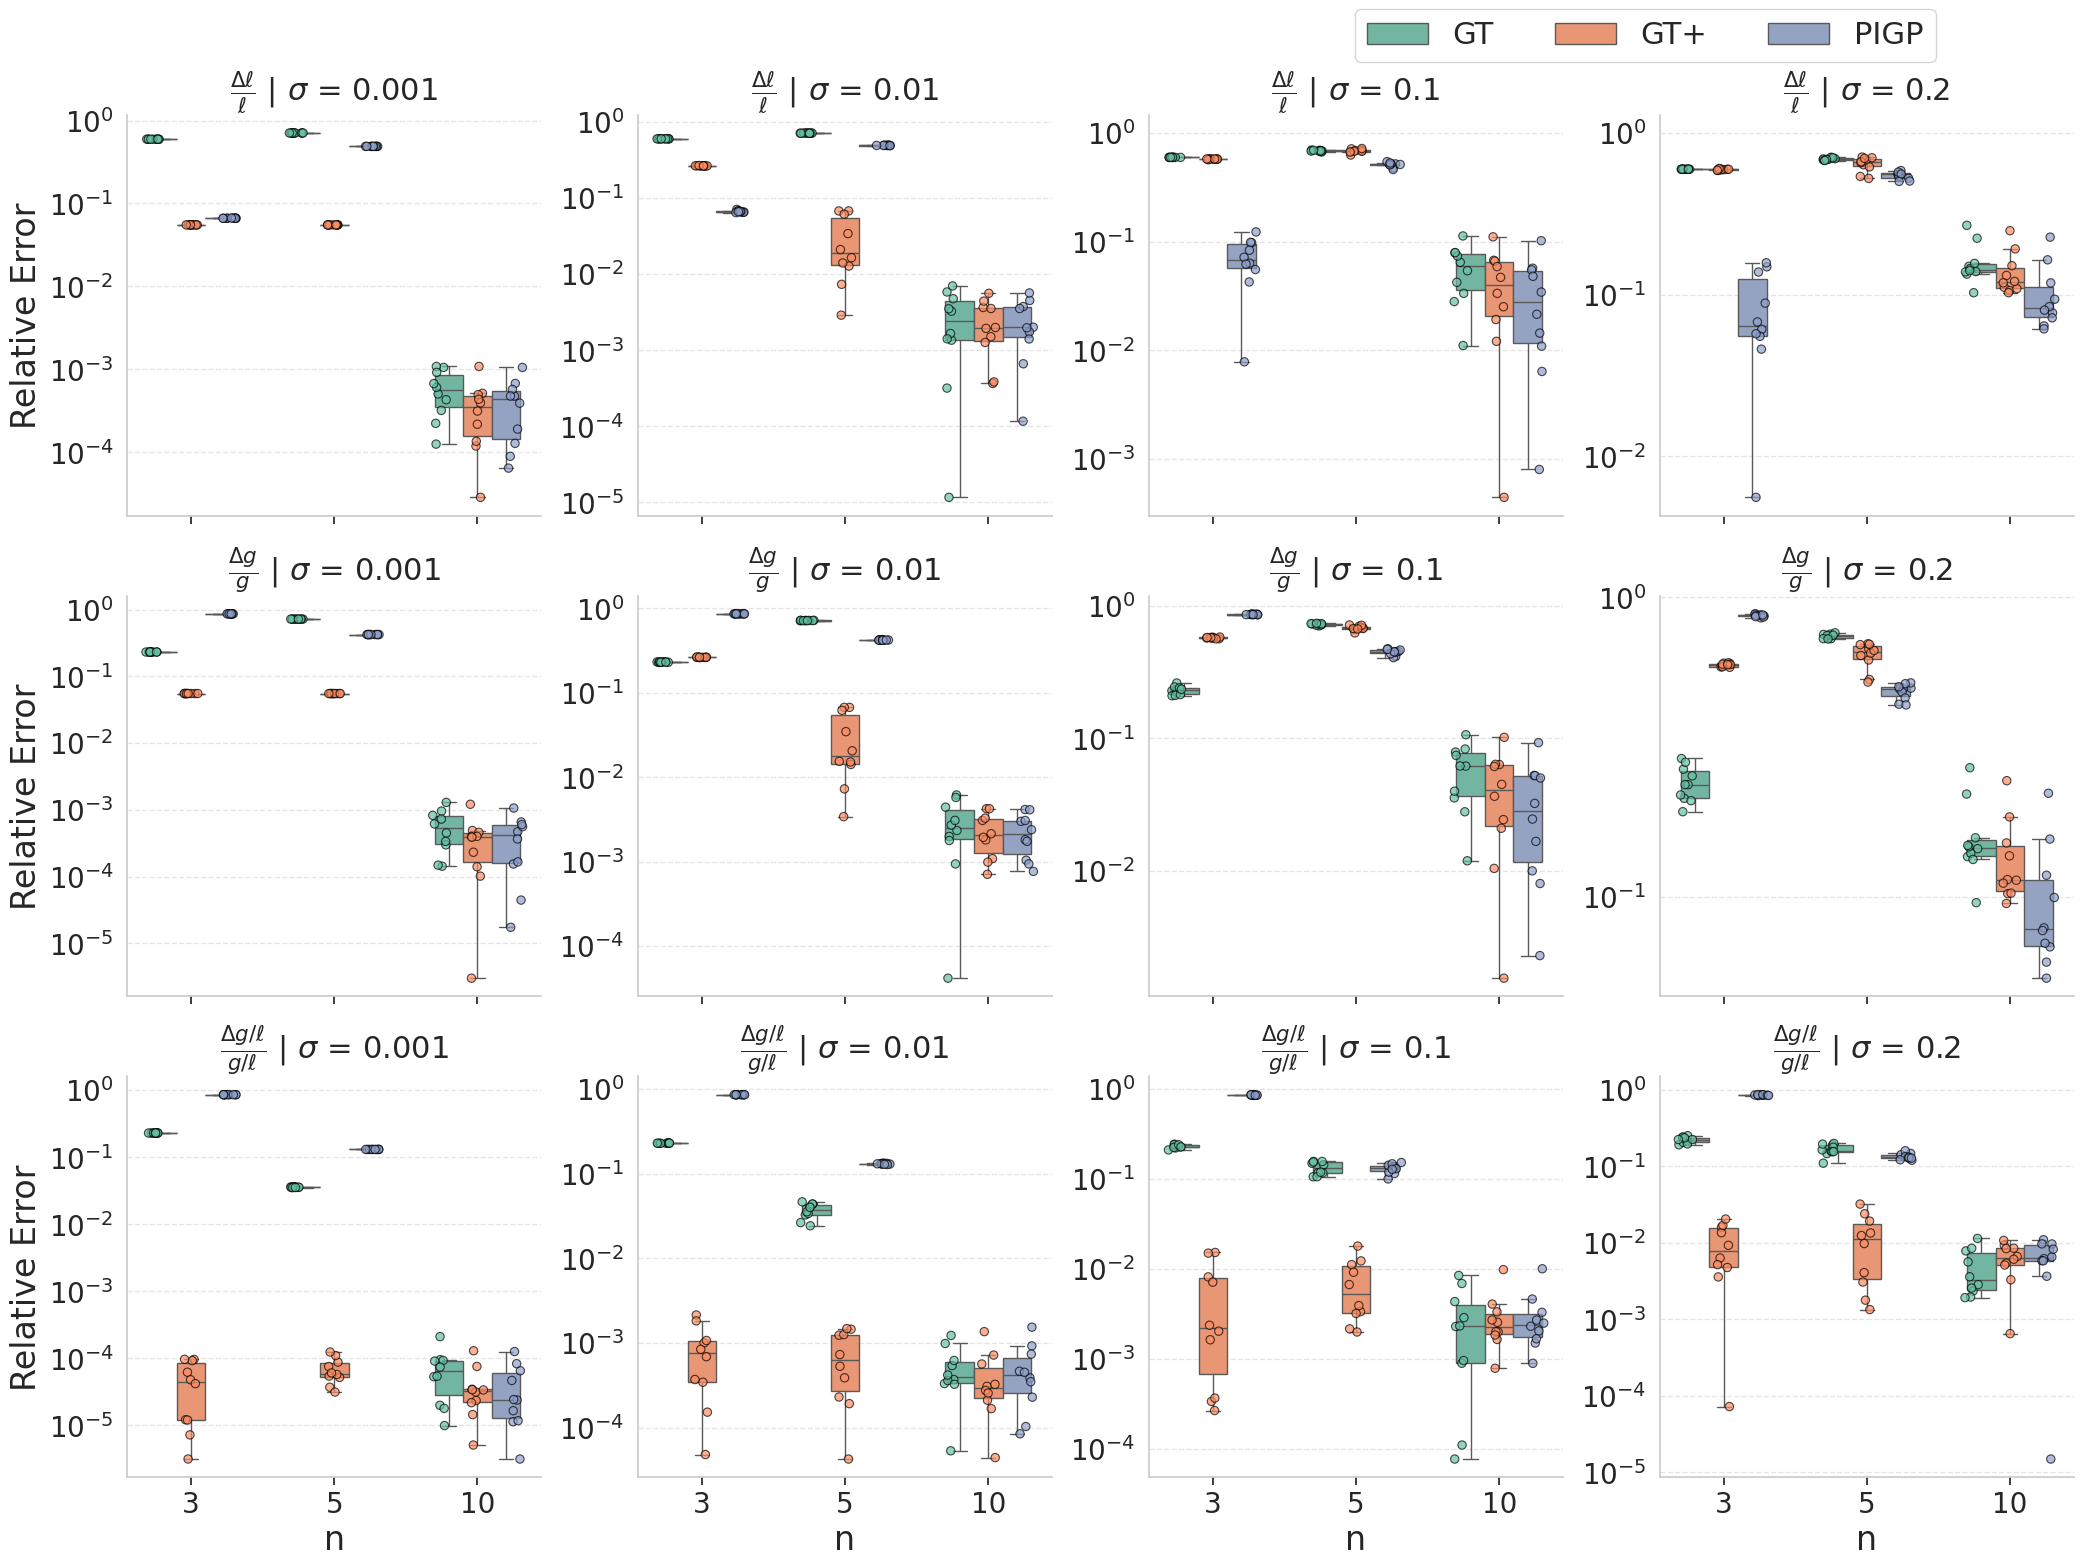

In [6]:
runs = 10
sigma_list = [0.001, 0.01, 0.1, 0.2]
n_list = [3, 5, 10]

modes = ["GT standard", "GT extra_npoints_extra_sigma", "PIGP standard"]

# corresponding filename modes and data directories
file_modes = ["GT", "GT", "PIGP"]
data_modes = ["standard", "extra_npoints_extra_sigma", "standard"]

param_names = [r'$\frac{\Delta \ell}{\ell}$', r'$\frac{\Delta g}{g}$', r'$\frac{\Delta g/\ell}{g/\ell}$']


# load data
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j in range(len(modes)):
            path = os.path.join(output_data_ex2, data_modes[j])
            for run in range(runs):
                fname = f"Ex1_{file_modes[j]}_n{npoints}_sigma{sigma:.3f}_{run}.npz"
                d = load_run(path, fname)

                all_AE[n_idx, sigma_idx, j, 0, run] = abs((d.learned_parameters[0] - d.true_parameters[0])/d.true_parameters[0])
                all_AE[n_idx, sigma_idx, j, 1, run] = abs((d.learned_parameters[1] - d.true_parameters[1])/d.true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs((d.learned_parameters[1] / d.learned_parameters[0] - d.true_parameters[1] / d.true_parameters[0])/(d.true_parameters[1] / d.true_parameters[0]))

# reshape
records = []
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for param_idx, param in enumerate(param_names):
                for run in range(runs):
                    records.append({
                        "n": n,
                        "sigma": sigma,
                        "mode": mode,
                        "param": param,
                        "AE": all_AE[n_idx, sigma_idx, mode_idx, param_idx, run]})

df = pd.DataFrame.from_records(records)

# categorical ordering
df["n"] = pd.Categorical(df["n"], categories=n_list, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
df["param"] = pd.Categorical(df["param"], categories=param_names, ordered=True)

sns.set(style="whitegrid")

g = sns.FacetGrid(
    df,
    row="param",
    col="sigma",
    height=5.25,
    aspect=1.0,
    sharey=False,
    margin_titles=False)

def box_and_points(data, **kwargs):
    ax = plt.gca()
    sns.boxplot(
        data=data,
        x="n",
        y="AE",
        hue="mode",
        dodge=True,
        width=0.6,
        showfliers=False,
        palette="Set2",
        ax=ax)
    sns.stripplot(
        data=data,
        x="n",
        y="AE",
        hue="mode",
        dodge=True,
        jitter=0.15,
        size=6,
        alpha=0.7,
        palette="Set2",
        edgecolor='black',
        linewidth = 0.8,
        ax=ax)
    if ax.legend_ is not None:
        ax.legend_.remove()

g.map_dataframe(box_and_points)
handles, labels = g.axes[0,0].get_legend_handles_labels()
print(labels)

g.figure.legend(
    handles[:3],
    ["GT", "GT+", "PIGP"],
    ncol=3,
    fontsize=22,
    loc=(0.65, 0.96))

# formatting
nrows, ncols = g.axes.shape
for i in range(nrows):
    for j in range(ncols):
        ax = g.axes[i, j]
        if i == 0 and (j == 3 or j == 2):
            ax.scatter([1, 1], [1, 0.1], alpha=0)
            ax.set_yticks([1e0, 1e-1])
        ax.tick_params(axis="both", labelsize=20)
        ax.set_yscale("log")
        ax.grid(
            True,
            axis="y",
            linestyle="--",
            alpha=0.5)
        ax.set_title(
            rf"{g.row_names[i]} | $\sigma$ = {g.col_names[j]}", fontsize=22)
        ax.tick_params(
            axis="x",
            which="both",
            bottom=True,
            labelbottom=(i == nrows - 1))

g.set_axis_labels("n", "Relative Error", fontsize=24)
g.figure.suptitle(" ", fontsize=24)
g.figure.tight_layout()
g.figure.set_size_inches(21, 15.75)

plt.savefig(os.path.join(save_dir, "Ex1_inverse.pdf"), bbox_inches="tight")

# grid based posteriors

In [7]:



_CANONICAL_ORDER = ["l_vals", "g_vals", "ls_vals", "A_vals"]


def _get_param_order(data):
    """Return the parameter axis order from data, falling back to canonical order."""
    if hasattr(data, "param_order"):
        return list(data.param_order)
    return [k for k in _CANONICAL_ORDER if hasattr(data, k)]


def _compute_marginal(mll, mode, param_order, n, marginalize_axes):
    """Marginalize a flat MLL grid: logsumexp for GT/PIGP, log-transform for Bayes.
    NaN entries (Cholesky failure for ill-conditioned params) are treated as -inf.
    The result is normalized log-probability (exp of it sums to 1 over the remaining
    grid), so panels/modes are directly comparable. Kept in log-space rather than
    exponentiated: a peaked posterior on a fine grid underflows to ~0 almost
    everywhere once exponentiated, which collapses a linear colormap to black."""
    shape = (n,) * len(param_order)
    if mode == "Bayes":
        if mll.size == n ** 3:
           
            mll_clean = np.where(np.isfinite(mll), mll, -np.inf)
            ll = logsumexp(mll_clean.reshape(shape), axis=marginalize_axes)
        else:
            ll = mll.reshape(shape)
        log_density = -np.log(ll.max() - ll + 1)
    else:
        
        mll_clean = np.where(np.isfinite(mll), mll, -np.inf)
        log_density = logsumexp(mll_clean.reshape(shape), axis=marginalize_axes)
    return -np.log(log_density.max() - log_density + 1)


def _get_grid_marginal(data, mode, plot_axes=None):
    """Compute the 2-D marginal posterior and its axis values for plot_axes."""
    param_order = _get_param_order(data)
    if plot_axes is None:
        plot_axes = param_order[:2]

    x_key, y_key = plot_axes
    x_ax = param_order.index(x_key)
    y_ax = param_order.index(y_key)
    marginalize_axes = tuple(i for i in range(len(param_order)) if i not in (x_ax, y_ax))

    n = len(np.asarray(getattr(data, param_order[0])))
    try:
        mll = np.asarray(data.mll_values)
    except:
        mll = np.asarray(data.dataterm_values)
    marginal = _compute_marginal(mll, mode, param_order, n, marginalize_axes)

    # after marginalization the remaining axes are in sorted (param_order) order;
    # transpose if the user wants x and y swapped relative to that
    remaining = sorted([x_ax, y_ax])
    if remaining[0] != x_ax:
        marginal = marginal.T

    x_vals = np.asarray(getattr(data, x_key))
    y_vals = np.asarray(getattr(data, y_key))
    return x_vals, y_vals, marginal


def _posterior_entropy(log_marginal):
    """Shannon entropy (nats) of a normalized log-posterior grid (exp(log_marginal)
    sums to 1). Scale-invariant: unlike the raw log-density, it only depends on the
    *shape* of the distribution, so it stays comparable across panels even when the
    absolute MLL scale differs by orders of magnitude (e.g. across sigma). Lower
    entropy = more concentrated/sharper posterior."""
    p = np.exp(log_marginal)
    contrib = p*log_marginal#np.where(p > 0, p * log_marginal, 0.0)
    return -np.sum(contrib)


def plot_grid_posterior(ax, data, mode, plot_axes=None, cmap="magenta", true_point=None,
                        vmin=None, vmax=None):
    """Plot a single posterior panel, marginalizing over all axes not in plot_axes.

    plot_axes: list of 2 key names (e.g. ["l_vals", "g_vals"]), defaults to first two
               in param_order (physical parameters). Use ["ls_vals", "A_vals"] for the
               calibration posterior.
    vmin/vmax: fix the colormap range, e.g. to share it across multiple panels.
    Returns (mesh, entropy): the QuadMesh (e.g. for a shared colorbar) and the
    posterior's entropy (scale-invariant sharpness measure, see _posterior_entropy).
    """
    x_vals, y_vals, marginal = _get_grid_marginal(data, mode, plot_axes)
    grids = np.meshgrid(x_vals, y_vals, indexing="ij")
    mesh = ax.pcolormesh(grids[0], grids[1], marginal, cmap=cmap, shading="auto",
                         vmin=vmin, vmax=vmax)
    if true_point is not None:
        ax.plot(*true_point, color="C2", marker="o", markersize=6)
    return mesh, _posterior_entropy(marginal)


def plot_posterior_grid(path, mode, sigma_list, npoints_list, possible_n,
                        plot_axes=None, cmap="magma", true_point=(2.5, 9.81), fname_append = None, title = None):
    """Plot a len(npoints_list) x len(sigma_list) grid of posterior panels for one mode.

    Layout: sigma runs across the top as column headers and npoints runs down the
    left as row headers (rather than repeating "n=.. noise=.." in every subplot).
    All panels share x/y axes; tick labels and axis labels (r"$\\ell$"/r"$g$") only
    appear on the bottom row / left column. Each panel keeps a small entropy
    annotation (H, scale-invariant sharpness measure, see _posterior_entropy) since
    sigma changes the absolute MLL scale by orders of magnitude, making a literal
    shared colorbar across sigma misleading.
    """
    n = possible_n[mode]
    nrows, ncols = len(npoints_list), len(sigma_list)

    panel_w, panel_h = 3.4, 3.2
    # header_w is wide enough to fit both the row-header text and the leftmost
    # panel's y-tick labels + y-label without the two colliding (both render at
    # whatever the notebook's rcParams font.size is, which can be large)
    header_w, header_h = 1.2, 0.5
    fig = plt.figure(figsize=(10.5, 7.5))#21, 15))
    gs = fig.add_gridspec(nrows + 1, ncols + 1,
                          width_ratios=[header_w] + [panel_w] * ncols,
                          height_ratios=[header_h] + [panel_h] * nrows,
                          left=0.10, right=0.95, top=0.9, bottom=0.08,
                          wspace=0.02, hspace=0.08)

    vmin = vmax = None

    # column headers (sigma) and row headers (npoints), each in their own blank cell
    for j, sigma in enumerate(sigma_list):
        hax = fig.add_subplot(gs[0, j + 1])
        hax.axis("off")
        hax.text(0.5, 0.5, rf"$\sigma$ = {sigma:.3f}", ha="center", va="center", fontsize = 24)
    for i, npoints in enumerate(npoints_list):
        hax = fig.add_subplot(gs[i + 1, 0])
        hax.axis("off")
        # x=0.25: pushed toward the outer/left edge of the header column, away from
        # the main panel's y-label/tick labels that sit at the column's right edge
        hax.text(0.0, 0.5, f"n = {npoints}\n", ha="center", va="center", rotation=90, fontsize = 24)

    axes = np.empty((nrows, ncols), dtype=object)
    ax0, mesh = None, None
    for i, npoints in enumerate(npoints_list):
        for j, sigma in enumerate(sigma_list):
            ax = fig.add_subplot(gs[i + 1, j + 1], sharex=ax0, sharey=ax0)
            ax0 = ax0 or ax
            axes[i, j] = ax
            if not fname_append:
                fname = f"{mode}_n{npoints}_sigma{sigma:.3f}_fulln{n}.npz" #%%%%%%%%%%%%%%%
            else:
                fname = f"{mode}_n{npoints}_sigma{sigma:.3f}_fulln{n}"+fname_append+".npz"
            data = load_run(path, fname)
            mesh, entropy = plot_grid_posterior(ax, data, mode, plot_axes, cmap,
                                                true_point, vmin=vmin, vmax=vmax)
            #ax.text(0.96, 0.94, f"H={abs(entropy):.2f}", transform=ax.transAxes,
            #        ha="right", va="top", color="white", fontsize = 18,
            #        bbox=dict(boxstyle="round", fc="black", alpha=0.45, pad=0.25))

            ax.tick_params(labelbottom=(i == nrows - 1), labelleft=(j == 0), labelsize = 20)
            if i == nrows - 1:
                ax.set_xlabel(r"$\ell$", fontsize = 24)
            if j == 0:
                ax.set_ylabel(r"$g$", fontsize = 24)
    if title:
        fig.suptitle(title, fontsize = 28)
    else:
        fig.suptitle(mode, fontsize = 28)
    fig.subplots_adjust(left=0.01)
    return fig, axes





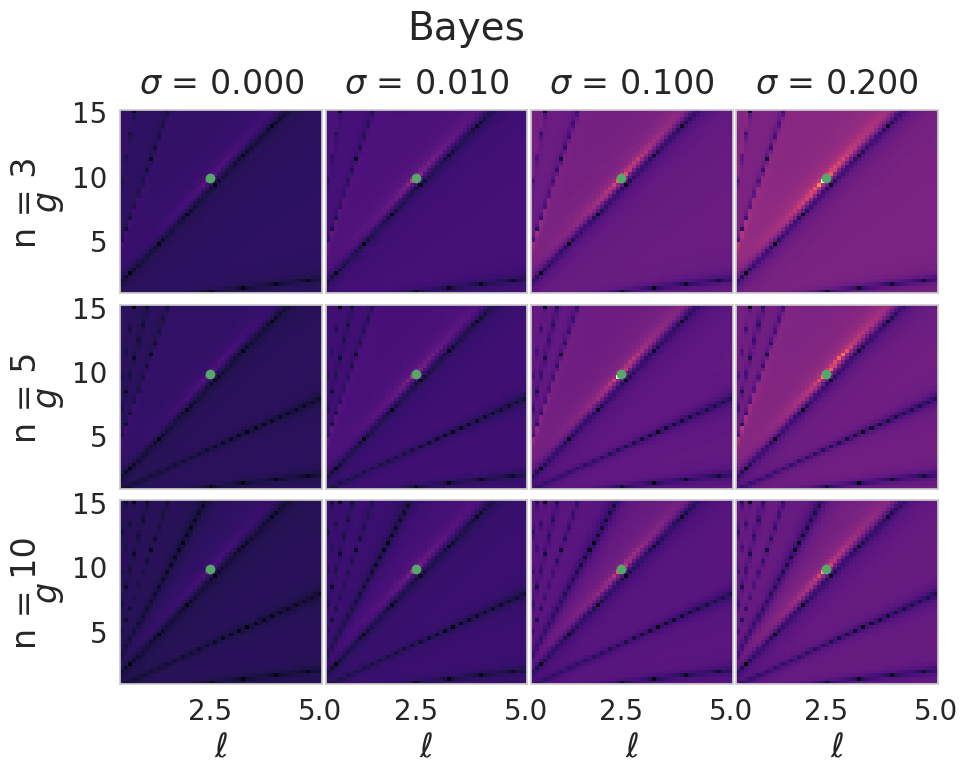

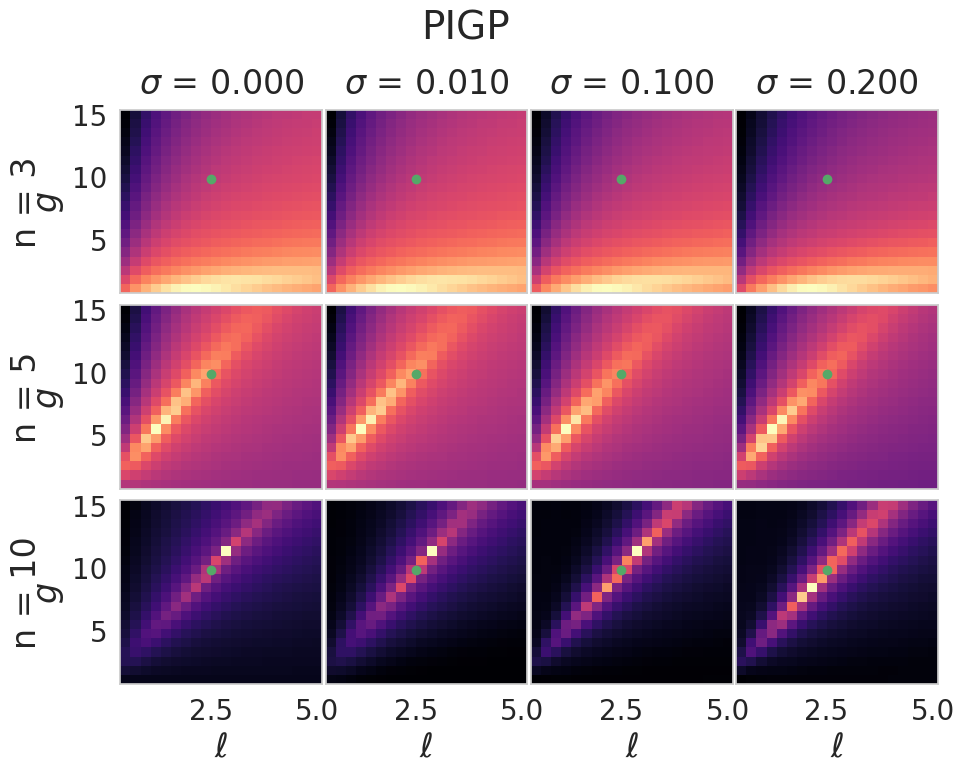

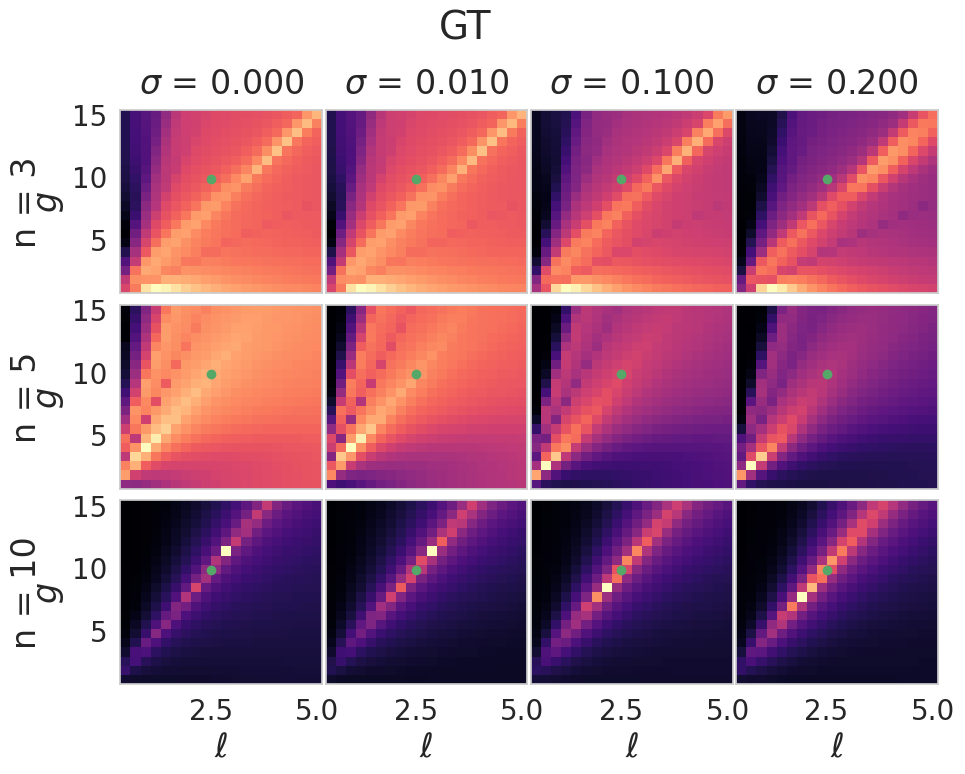

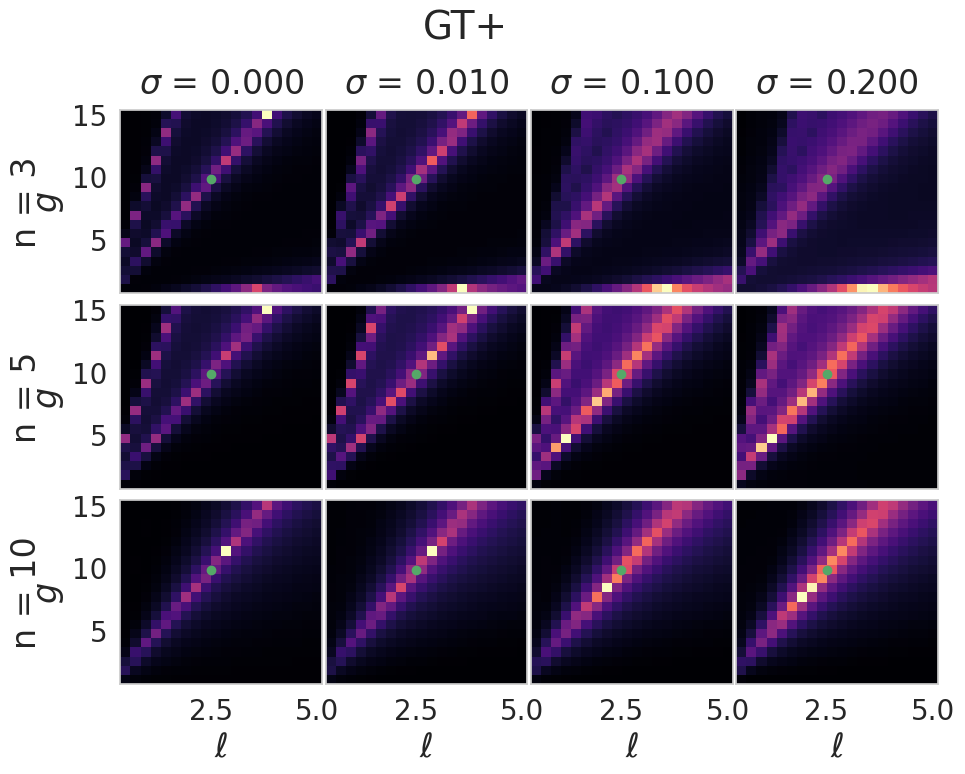

In [9]:
base_dir = "/home/johanna/Documents/PhD/project/github/GhostTasking"
data_mode = "standard"
grid_path_plus  = os.path.join(base_dir, "Experiment1_Tripendulum", "grid_evaluation", "output_data",  "extra_npoints_extra_sigma")
grid_path  = os.path.join(base_dir, "Experiment1_Tripendulum", "grid_evaluation", "output_data",  "standard")
grid_path_bayes  = os.path.join(base_dir, "Experiment1_Tripendulum", "grid_evaluation", "output_data", "Bayes")

sigma_list    = [0.001, 0.01, 0.1, 0.2]
npoints_list  = [3, 5, 10]
possible_n    = {"GT": 20, "PIGP": 20, "Bayes": 50}
fig, axes = plot_posterior_grid(grid_path_bayes, "Bayes", sigma_list, npoints_list, possible_n, cmap = "magma", fname_append = None)
#plt.savefig(os.path.join(save_dir, "Ex2_posterior_Bayes.pdf"),bbox_inches='tight' )

fig, axes = plot_posterior_grid(grid_path, "PIGP", sigma_list, npoints_list, possible_n, cmap = "magma", fname_append = "_2")
#plt.savefig(os.path.join(save_dir, "Ex2_posterior_PIGP.pdf"),bbox_inches='tight' )
fig, axes = plot_posterior_grid(grid_path, "GT", sigma_list, npoints_list, possible_n, cmap = "magma", fname_append = None)
#plt.savefig(os.path.join(save_dir, "Ex2_posterior_GT.pdf"),bbox_inches='tight' )
fig, axes = plot_posterior_grid(grid_path_plus, "GT", sigma_list, npoints_list, possible_n, cmap = "magma", fname_append = None, title = "GT+")
#plt.savefig(os.path.join(save_dir, "Ex2_posterior_GT+.pdf"),bbox_inches='tight' )


# Forward problem

In [10]:
def plot_timeseries(fig, data, num_tasks, task_labels, outer_spec=None, title="Forward fit",
                    grid_rows=None, xlim=None, task_rows=None):
    """Plot stacked per-task time series into outer_spec, or the full figure if None.

    grid_rows: total rows of the inner grid (default num_tasks). If larger, the
               extra (empty) rows sit at the BOTTOM, so every panel keeps exactly
               the same height as a taller neighbouring column.
    xlim:      shared (xmin, xmax) so the t-axis matches across columns.
    NOTE: for exactly equal-sized panels, use a figure WITHOUT constrained_layout
    (constrained_layout shrinks panels that carry a title / xlabel).
    """
    from matplotlib.ticker import MaxNLocator
    rows = grid_rows
    if task_rows is None:
        task_rows = list(range(num_tasks))
    if outer_spec is None:
        inner = gridspec.GridSpec(rows, 1, figure=fig, hspace=0.05)
    else:
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, 1, subplot_spec=outer_spec, hspace=0.05
        )
    first_ax = None
    for i, row in enumerate(task_rows):                 # rows 0..num_tasks-1; blank rows at bottom
        mask_test  = data.test_x[..., -1] == i
        mask_train = data.train_x[..., -1] == i
        t_test  = data.test_x[mask_test, 0]
        t_train = data.train_x[mask_train, 0]

        ax = fig.add_subplot(inner[row, 0], sharex=first_ax)
        ax.grid(False)
        first_ax = first_ax or ax
        ax.fill_between(t_test, data.lower[mask_test], data.upper[mask_test], alpha=0.3)
        ax.plot(t_test, data.mean[mask_test], "b", linewidth=4)
       
        ax.plot(t_test, data.test_y[mask_test], "r--", linewidth = 4)
        ax.plot(t_train, data.train_y[mask_train], "k*", markersize = 15)
        ax.set_ylabel(task_labels[row], fontsize=22)
        # prune the top/bottom y-tick labels so they don't collide with the
        # neighbouring stacked panel's boundary ticks (hspace is tiny)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune="both"))
        if xlim is not None:
            ax.set_xlim(xlim)

        # per-task RMSE annotation (like the forward problem in Ex1_metrics)
        err = data.mean[mask_test] - data.test_y[mask_test]
        rmse = float(np.sqrt((np.asarray(err) ** 2).mean()))
        ax.text(0.97, 0.94, f"RMSE={rmse:.4f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=20, color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.55))
        if i < num_tasks - 1:
           #print("here", i)
            ax.tick_params(labelbottom=False, bottom=False, labelsize=20)
        else:
            ax.set_xlabel(r"$t$", fontsize=22)
            ax.tick_params(labelsize=20)

        if i == 0:
            ax.set_title(title, fontsize=24)

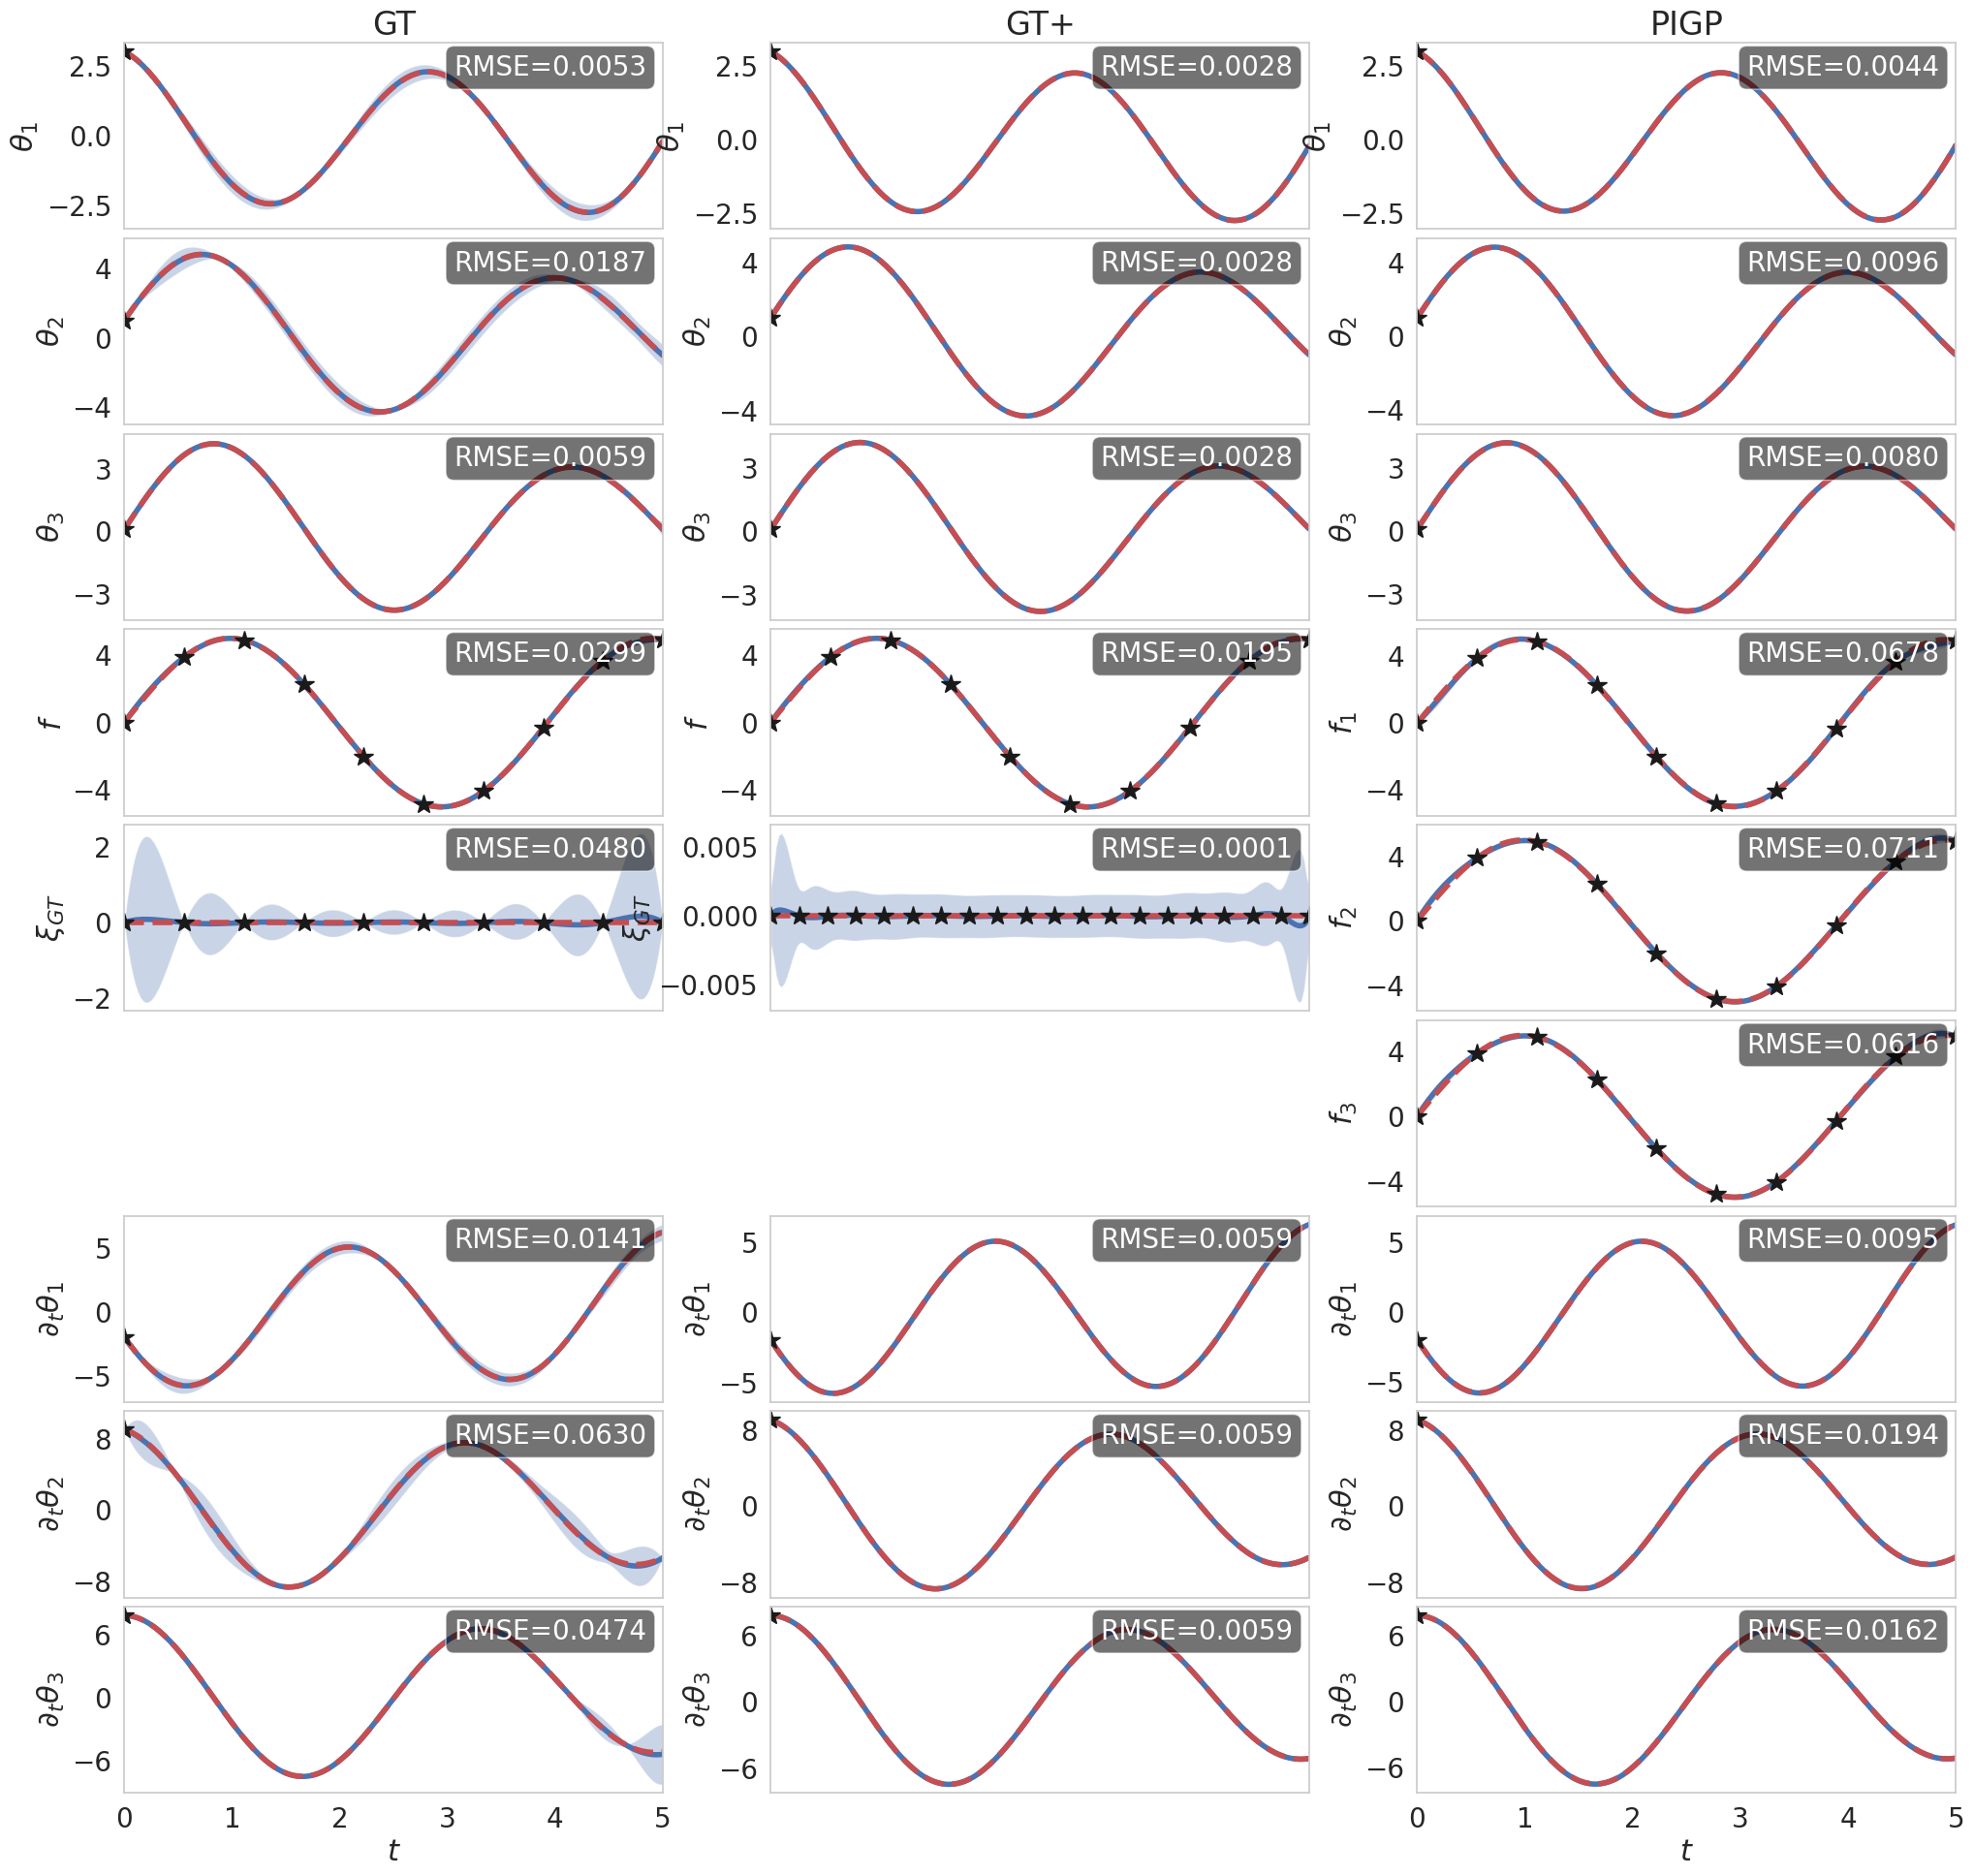

In [17]:
# GT and PIGP forward fits side by side (aligned time axis, equal-sized panels)
num_tasks = {"GT": 8, "PIGP": 9}
task_labels = {"GT":  [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$f$", r"$\xi_{GT}$", " ",r"$\partial_t\theta_1$", r"$\partial_t\theta_2$", r"$\partial_t\theta_3$"],
               "GT+":  [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$f$", r"$\xi_{GT}$", " ",r"$\partial_t\theta_1$", r"$\partial_t\theta_2$", r"$\partial_t\theta_3$"],
               "PIGP": [r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$f_1$", r"$f_2$", r"$f_3$", r"$\partial_t\theta_1$", r"$\partial_t\theta_2$", r"$\partial_t\theta_3$"]}

data_dir = os.path.join(output_data_ex2, "forward")
s = {"PIGP":"", "GT":"", "GT+":""}
datas = {mode: load_run(data_dir, f"Ex1_{mode}.npz") for mode in ["GT", "GT+", "PIGP"]}

grid_rows = max(num_tasks.values())                      # both columns use the same #rows
tcat = np.concatenate([np.asarray(d.test_x[:, 0]) for d in datas.values()])
xlim = (float(tcat.min()), float(tcat.max()))            # shared t-axis across columns

# no constrained_layout: a plain fixed-margin gridspec keeps every cell exactly equal
fig = plt.figure(figsize=(21, 21))
outer = fig.add_gridspec(1, 3, left=0.07, right=0.97, top=0.93, bottom=0.07, wspace=0.2)

mode = "GT"
plot_timeseries(fig, datas[mode], num_tasks=8,
                    task_labels=task_labels[mode], outer_spec=outer[0, 0],
                    title=mode, grid_rows=9, xlim=xlim, task_rows = [0,1,2,3,4, 6,7, 8])

mode = "GT+"
plot_timeseries(fig, datas[mode], num_tasks=9,
                    task_labels=task_labels[mode], outer_spec=outer[0, 1],
                   title="GT+", grid_rows=9, xlim=xlim, task_rows = [0,1,2,3,4, 6,7, 8])
mode = "PIGP"
plot_timeseries(fig, datas[mode], num_tasks=9,
                    task_labels=task_labels[mode], outer_spec=outer[0, 2],
                   title=mode, grid_rows=9, xlim=xlim)#, task_rows = [0,1,2,3, 4,5,6,7, 8])
plt.savefig(os.path.join(save_dir, f"Ex1_forward.pdf"), bbox_inches="tight")